# Оптимизатор и baseline

In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.max_columns = 100
pd.options.display.float_format = lambda x: f'{x:,.2f}'.replace(',', ' ')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

HERE = Path.cwd().resolve()
if (HERE / 'backend').exists():
    ROOT = HERE
elif (HERE.parent / 'backend').exists():
    ROOT = HERE.parent
else:
    ROOT = Path('/Users/sergey/PycharmProjects/WB_hackaton')

DATA_DIR = ROOT / 'backend' / 'data'
TRASH_DIR = ROOT / 'trash'
TARGET_COL = 'target_2h'
RANDOM_STATE = 42
EDA_SAMPLE_N = 150_000

## Загрузка

In [2]:
EDA_DIR = TRASH_DIR / 'EDA'
opt_agg = pd.read_csv(EDA_DIR / 'dispatch_plan_agg.csv')
base_full = pd.read_csv(EDA_DIR / 'baseline_plan_agg.csv')
base_under_raw = pd.read_csv(EDA_DIR / 'baseline_underfill.csv')

group_cols = ['warehouse_id', 'office_from_id', 'route_id', 'horizon', 'timestamp', 'distance_km']
sum_cols = ['vehicles_count', 'cost_fixed', 'cost_underload', 'cost_wait', 'cost_total', 'empty_capacity_units']
first_cols = ['demand_new', 'demand_carried_over', 'total_available', 'actually_shipped', 'leftover_stock']

base_under = (
    base_under_raw.groupby(group_cols, as_index=False)
    .agg({**{c: 'sum' for c in sum_cols}, **{c: 'first' for c in first_cols}})
)

for df in [opt_agg, base_full, base_under]:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['route_id'] = df['route_id'].astype(str)

In [3]:
opt_agg['scenario'] = 'opt'
base_full['scenario'] = 'base_full'
base_under['scenario'] = 'base_under'

scenario_map = {
    'opt': 'Оптимизатор',
    'base_full': 'Baseline №1',
    'base_under': 'Baseline №2',
}
scenario_order = ['opt', 'base_full', 'base_under']
horizon_order = ['A: now', 'B: +2h', 'C: +4h', 'D: +6h']

cmp = pd.concat([opt_agg, base_full, base_under], ignore_index=True)
cmp['scenario_label'] = cmp['scenario'].map(scenario_map)

In [4]:
print('строк opt', len(opt_agg))
print('строк base1', len(base_full))
print('строк base2', len(base_under))
print('маршрутов', cmp['route_id'].nunique())

строк opt 20
строк base1 20
строк base2 20
маршрутов 5


## Сводка

In [5]:
summary_df = (
    cmp.groupby('scenario', dropna=False)
    .apply(lambda df: pd.Series({
        'routes': df['route_id'].nunique(),
        'demand_total': (df['demand_new'] + df['demand_carried_over']).sum(),
        'shipped': df['actually_shipped'].sum(),
        'leftover': df['leftover_stock'].sum(),
        'empty_cap': df['empty_capacity_units'].sum(),
        'cost_total': df['cost_total'].sum(),
        'cpu': df['cost_total'].sum() / df['actually_shipped'].sum(),
        'fill_rate': df['actually_shipped'].sum() / (df['demand_new'] + df['demand_carried_over']).sum(),
    }))
    .reindex(scenario_order)
    .rename(index=scenario_map)
    .reset_index(names='scenario')
)
display(summary_df)

,scenario,routes,demand_total,shipped,leftover,empty_cap,cost_total,cpu,fill_rate
0,Оптимизатор,5.00,1 702.00,1 702.00,0.00,13.00,207 077.53,121.67,1.00
1,Baseline №1,5.00,1 702.00,1 702.00,0.00,44.00,278 640.04,163.71,1.00
2,Baseline №2,5.00,1 702.00,1 638.00,64.00,0.00,322 124.76,196.66,0.96


## Стоимость

/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


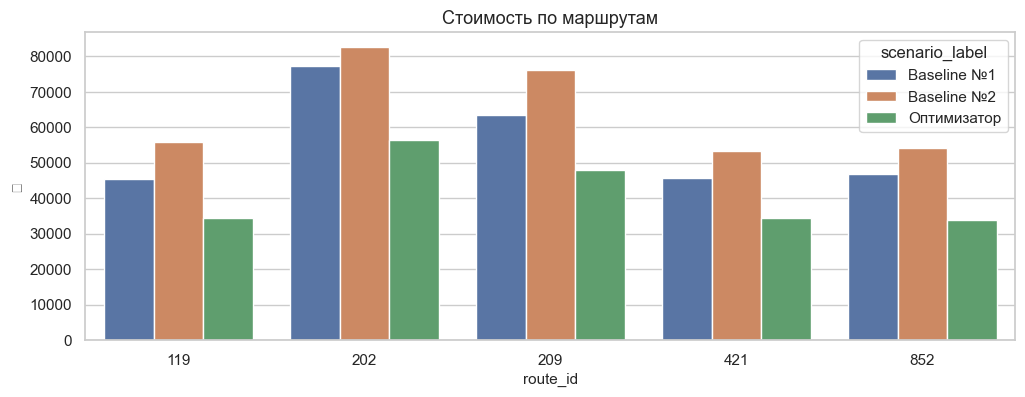

In [6]:
route_cost_df = (
    cmp.groupby(['scenario_label', 'route_id'], dropna=False)['cost_total']
    .sum()
    .reset_index()
)
route_order = sorted(route_cost_df['route_id'].unique(), key=lambda x: int(x))

plt.figure(figsize=(12, 4))
sns.barplot(data=route_cost_df, x='route_id', y='cost_total', hue='scenario_label', order=route_order)
plt.title('Стоимость по маршрутам')
plt.xlabel('route_id')
plt.ylabel('₽')
plt.show()

/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


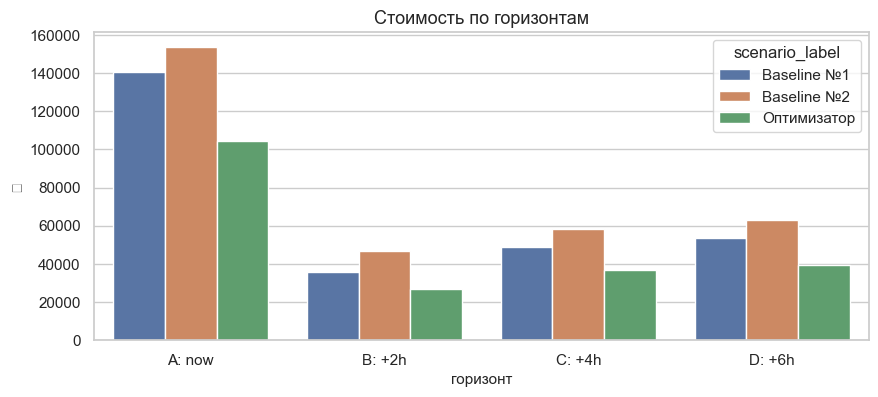

In [7]:
horizon_cost_df = (
    cmp.groupby(['scenario_label', 'horizon'], dropna=False)['cost_total']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=horizon_cost_df, x='horizon', y='cost_total', hue='scenario_label', order=horizon_order)
plt.title('Стоимость по горизонтам')
plt.xlabel('горизонт')
plt.ylabel('₽')
plt.show()

In [8]:
cpu_df = (
    cmp.groupby('scenario', dropna=False)
    .apply(lambda df: df['cost_total'].sum() / df['actually_shipped'].sum())
    .reindex(scenario_order)
    .rename(index=scenario_map)
    .reset_index(name='cpu')
    .rename(columns={'index': 'scenario'})
)
display(cpu_df)

,scenario,cpu
0,Оптимизатор,121.67
1,Baseline №1,163.71
2,Baseline №2,196.66


/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8203/652131489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cpu_df, x='scenario', y='cpu', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])
/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


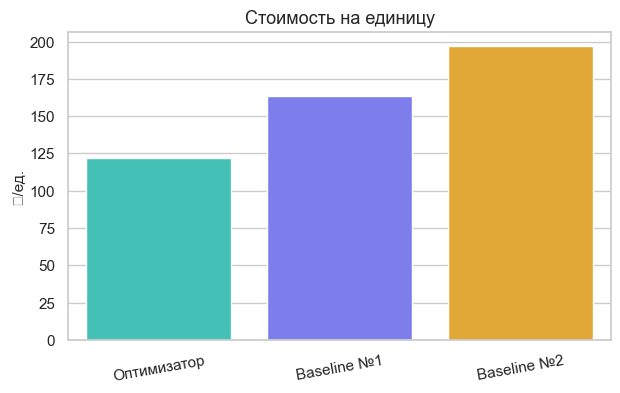

In [9]:
plt.figure(figsize=(7, 4))
sns.barplot(data=cpu_df, x='scenario', y='cpu', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])
plt.title('Стоимость на единицу')
plt.xlabel('')
plt.ylabel('₽/ед.')
plt.xticks(rotation=10)
plt.show()

## Покрытие

In [10]:
fill_rate_df = (
    cmp.groupby('scenario', dropna=False)
    .apply(lambda df: df['actually_shipped'].sum() / (df['demand_new'] + df['demand_carried_over']).sum())
    .reindex(scenario_order)
    .rename(index=scenario_map)
    .reset_index(name='fill_rate')
    .rename(columns={'index': 'scenario'})
)
display(fill_rate_df)

,scenario,fill_rate
0,Оптимизатор,1.00
1,Baseline №1,1.00
2,Baseline №2,0.96


/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8203/240882587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fill_rate_df, x='scenario', y='fill_rate', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])


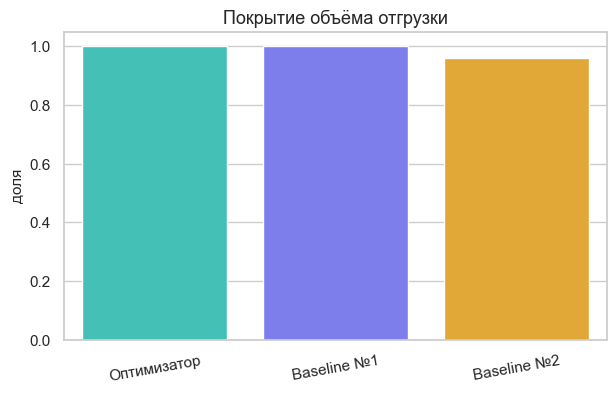

In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(data=fill_rate_df, x='scenario', y='fill_rate', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])
plt.title('Покрытие объёма отгрузки')
plt.xlabel('')
plt.ylabel('доля')
plt.ylim(0, 1.05)
plt.xticks(rotation=10)
plt.show()

In [12]:
shipped_df = (
    cmp.groupby('scenario', dropna=False)['actually_shipped']
    .sum()
    .reindex(scenario_order)
    .rename(index=scenario_map)
    .reset_index(name='shipped')
    .rename(columns={'index': 'scenario'})
)
display(shipped_df)

,scenario,shipped
0,Оптимизатор,1 702.00
1,Baseline №1,1 702.00
2,Baseline №2,1 638.00


/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8203/1290305948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shipped_df, x='scenario', y='shipped', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])


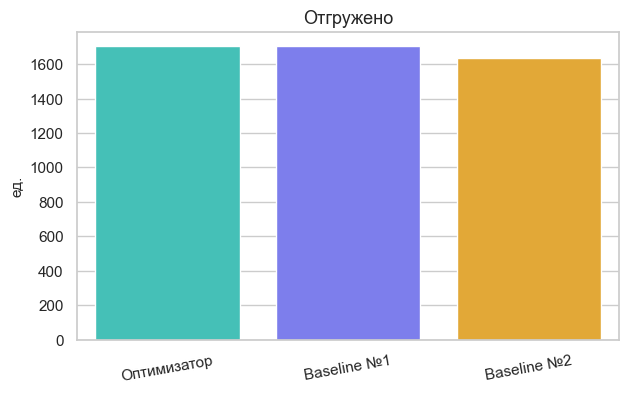

In [13]:
plt.figure(figsize=(7, 4))
sns.barplot(data=shipped_df, x='scenario', y='shipped', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])
plt.title('Отгружено')
plt.xlabel('')
plt.ylabel('ед.')
plt.xticks(rotation=10)
plt.show()

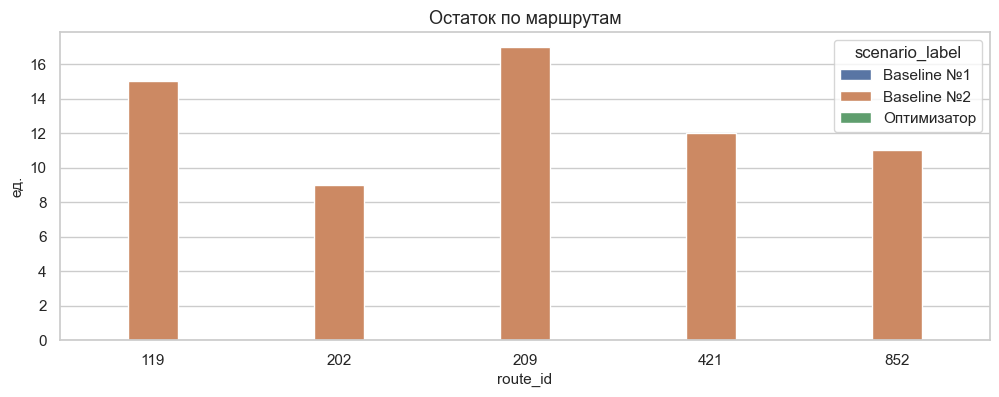

In [14]:
leftover_route_df = (
    cmp.groupby(['scenario_label', 'route_id'], dropna=False)['leftover_stock']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 4))
sns.barplot(data=leftover_route_df, x='route_id', y='leftover_stock', hue='scenario_label', order=route_order)
plt.title('Остаток по маршрутам')
plt.xlabel('route_id')
plt.ylabel('ед.')
plt.show()

In [15]:
empty_cap_df = (
    cmp.groupby('scenario', dropna=False)['empty_capacity_units']
    .sum()
    .reindex(scenario_order)
    .rename(index=scenario_map)
    .reset_index(name='empty_capacity')
    .rename(columns={'index': 'scenario'})
)
display(empty_cap_df)

,scenario,empty_capacity
0,Оптимизатор,13.00
1,Baseline №1,44.00
2,Baseline №2,0.00


/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8203/1002743522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=empty_cap_df, x='scenario', y='empty_capacity', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])


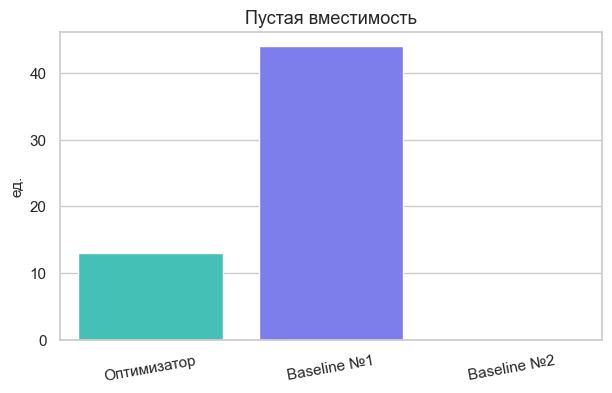

In [16]:
plt.figure(figsize=(7, 4))
sns.barplot(data=empty_cap_df, x='scenario', y='empty_capacity', palette=['#30D5C8', '#6A6CFF', '#FFB11A'])
plt.title('Пустая вместимость')
plt.xlabel('')
plt.ylabel('ед.')
plt.xticks(rotation=10)
plt.show()